# Machine Learning Engineer Nanodegree
## Unsupervised Learning
## Project: Creating Customer Segments

Welcome to the third project of the Machine Learning Engineer Nanodegree! In this notebook, some template code has already been provided for you, and it will be your job to implement the additional functionality necessary to successfully complete this project. Sections that begin with **'Implementation'** in the header indicate that the following block of code will require additional functionality which you must provide. Instructions will be provided for each section and the specifics of the implementation are marked in the code block with a `'TODO'` statement. Please be sure to read the instructions carefully!

In addition to implementing code, there will be questions that you must answer which relate to the project and your implementation. Each section where you will answer a question is preceded by a **'Question X'** header. Carefully read each question and provide thorough answers in the following text boxes that begin with **'Answer:'**. Your project submission will be evaluated based on your answers to each of the questions and the implementation you provide.  

>**Note:** Code and Markdown cells can be executed using the **Shift + Enter** keyboard shortcut. In addition, Markdown cells can be edited by typically double-clicking the cell to enter edit mode.

## Getting Started

In this project, you will analyze a dataset containing data on various customers' annual spending amounts (reported in *monetary units*) of diverse product categories for internal structure. One goal of this project is to best describe the variation in the different types of customers that a wholesale distributor interacts with. Doing so would equip the distributor with insight into how to best structure their delivery service to meet the needs of each customer.

The dataset for this project can be found on the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Wholesale+customers). For the purposes of this project, the features `'Channel'` and `'Region'` will be excluded in the analysis — with focus instead on the six product categories recorded for customers.

Run the code block below to load the wholesale customers dataset, along with a few of the necessary Python libraries required for this project. You will know the dataset loaded successfully if the size of the dataset is reported.

In [9]:
# Import libraries necessary for this project
import numpy as np
import pandas as pd
from IPython.display import display # Allows the use of display() for DataFrames

# Import supplementary visualizations code visuals.py
import visuals as vs

# Pretty display for notebooks
%matplotlib inline

# Load the wholesale customers dataset
try:
    data = pd.read_csv("customers.csv")
    data.drop(['Region', 'Channel'], axis = 1, inplace = True)
    print("Wholesale customers dataset has {} samples with {} features each.".format(*data.shape))
except:
    print("Dataset could not be loaded. Is the dataset missing?")

Wholesale customers dataset has 440 samples with 6 features each.


## Data Exploration
In this section, you will begin exploring the data through visualizations and code to understand how each feature is related to the others. You will observe a statistical description of the dataset, consider the relevance of each feature, and select a few sample data points from the dataset which you will track through the course of this project.

Run the code block below to observe a statistical description of the dataset. Note that the dataset is composed of six important product categories: **'Fresh'**, **'Milk'**, **'Grocery'**, **'Frozen'**, **'Detergents_Paper'**, and **'Delicatessen'**. Consider what each category represents in terms of products you could purchase.

In [2]:
# Display a description of the dataset
display(data.describe())

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


### Implementation: Selecting Samples
To get a better understanding of the customers and how their data will transform through the analysis, it would be best to select a few sample data points and explore them in more detail. In the code block below, add **three** indices of your choice to the `indices` list which will represent the customers to track. It is suggested to try different sets of samples until you obtain customers that vary significantly from one another.

In [10]:
# TODO: Select three indices of your choice you wish to sample from the dataset
indices = [0, 1, 2]

# Create a DataFrame of the chosen samples
samples = pd.DataFrame(data.loc[indices], columns = data.keys()).reset_index(drop = True)
print("Chosen samples of wholesale customers dataset:")
display(samples)

Chosen samples of wholesale customers dataset:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844


<Axes: >

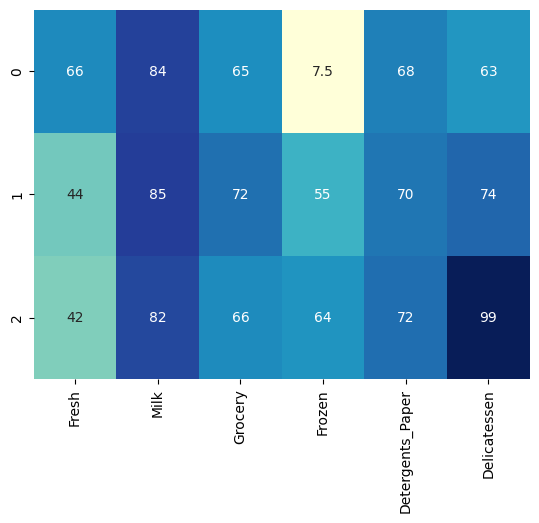

In [11]:
import seaborn as sns

percentiles_data = 100 * data.rank(pct=True)
percentiles_samples = percentiles_data.loc[indices]
sns.heatmap(percentiles_samples, annot=True, cmap="YlGnBu", cbar=False)

### Question 1
Consider the total purchase cost of each product category and the statistical description of the dataset above for your sample customers.  

* What kind of establishment (customer) could each of the three samples you've chosen represent?

**Hint:** Examples of establishments include places like markets, cafes, delis, wholesale retailers, among many others. Avoid using names for establishments, such as saying *"McDonalds"* when describing a sample customer as a restaurant. You can use the mean values for reference to compare your samples with. The mean values are as follows:

* Fresh: 12000.2977
* Milk: 5796.2
* Grocery: 7951.3
* Frozen: 3071.9
* Detergents_paper: 2881.4
* Delicatessen: 1524.8

Knowing this, how do your samples compare? Does that help in driving your insight into what kind of establishments they might be? 


**Answer:** 

Sample 0:

This customer has a high spending on Fresh and Milk, but very low Frozen products. This suggests a business that relies on fresh ingredients rather than stored food. Therefore, this sample likely represents a restaurant or café.

Sample 1:

This customer has high spending on Grocery, Milk, and Detergents_Paper. This indicates a business that sells a wide variety of daily-use products. Therefore, this sample likely represents a supermarket or retail store.

Sample 2:

This customer shows extremely high spending on Delicatessen products, along with relatively high Milk and Detergents_Paper. This suggests a business focused on prepared or specialty foods. Therefore, this sample likely represents a deli shop or catering service.

## Improve selecting indices of Samples:

Instead of selecting arbitrary indices, I chose three customers based on their total annual spending across all product categories. Specifically, I selected:

One customer with the lowest total spending
One customer with a median (middle) total spending
One customer with the highest total spending

This approach ensures that the selected samples represent diverse customer behaviors, ranging from small-scale buyers to large-scale purchasers.

By doing so, it becomes easier to observe clear differences in purchasing patterns and better understand how customer types vary across the dataset. This selection method is more informative than choosing consecutive rows, which may not capture the full variability of the data.

In [14]:
# Create a total spending column
data['Total'] = data.sum(axis=1)

# Select customers with low, medium, and high total spending
low_spender = data['Total'].idxmin()
high_spender = data['Total'].idxmax()
mid_spender = data['Total'].sort_values().index[len(data)//2]

# Combine indices
indices = [low_spender, mid_spender, high_spender]

# Create samples DataFrame (without Total column)
samples = data.loc[indices].drop('Total', axis=1).reset_index(drop=True)

print("Chosen samples of wholesale customers dataset:")
display(samples)

Chosen samples of wholesale customers dataset:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,622,55,137,75,7,8
1,20918,1916,1573,1960,231,961
2,16117,46197,92780,1026,40827,2944


<Axes: >

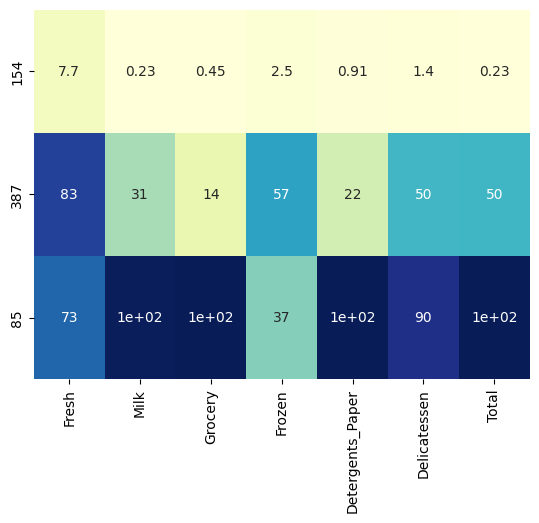

In [15]:
import seaborn as sns

percentiles_data = 100 * data.rank(pct=True)
percentiles_samples = percentiles_data.loc[indices]
sns.heatmap(percentiles_samples, annot=True, cmap="YlGnBu", cbar=False)

## Answer_2 of Q1
Sample 0:

This customer shows extremely low spending across all product categories, especially compared to the dataset means. All values are far below average, indicating very limited purchasing activity. This pattern is typical of a very small establishment, such as a local convenience shop or a very small café, which operates with minimal inventory and low customer demand.

Sample 1:

This customer has significantly higher spending on Fresh products, while other categories remain relatively low compared to the mean values. This suggests a business that relies heavily on fresh ingredients but does not purchase large amounts of grocery or household goods. This pattern is consistent with a restaurant or food service establishment, such as a mid-sized restaurant that focuses on fresh food preparation.

Sample 2:

This customer has extremely high spending across multiple categories, especially Milk, Grocery, and Detergents_Paper, far exceeding the dataset averages. This indicates a large-scale buyer that purchases in bulk across almost all product types. This behavior is typical of a large supermarket or wholesale distributor, where a wide variety of goods is needed in high quantities to serve many customers or retailers.

### Implementation: Feature Relevance
One interesting thought to consider is if one (or more) of the six product categories is actually relevant for understanding customer purchasing. That is to say, is it possible to determine whether customers purchasing some amount of one category of products will necessarily purchase some proportional amount of another category of products? We can make this determination quite easily by training a supervised regression learner on a subset of the data with one feature removed, and then score how well that model can predict the removed feature.

In the code block below, you will need to implement the following:
 - Assign `new_data` a copy of the data by removing a feature of your choice using the `DataFrame.drop` function.
 - Use `sklearn.model_selection.train_test_split` to split the dataset into training and testing sets.
   - Use the removed feature as your target label. Set a `test_size` of `0.25` and set a `random_state`.
 - Import a decision tree regressor, set a `random_state`, and fit the learner to the training data.
 - Report the prediction score of the testing set using the regressor's `score` function.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

results = {}

for feature in data.columns:
    # TODO: Make a copy of the DataFrame, using the 'drop' function to drop the given feature
    new_data = data.drop([feature], axis=1)
    
    y = data[feature]
    
    # TODO: Split the data into training and testing sets(0.25) using the given feature as the target
    # Set a random state.
    X_train, X_test, y_train, y_test = train_test_split(
        new_data, y, test_size=0.25, random_state=42
    )
    
    # TODO: Create a decision tree regressor and fit it to the training set
    regressor = DecisionTreeRegressor(random_state=42)
    regressor.fit(X_train, y_train)
    
    # TODO: Report the score of the prediction using the testing set
    score = regressor.score(X_test, y_test)
    
    results[feature] = score

# Display the results
for k, v in results.items():
    print(f"{k}: {v:.3f}")

Fresh: 0.558
Milk: 0.251
Grocery: 0.707
Frozen: 0.183
Detergents_Paper: 0.485
Delicatessen: -11.389
Total: 0.721


### Question 2

* Which feature did you attempt to predict? 
* What was the reported prediction score? 
* Is this feature necessary for identifying customers' spending habits?

**Hint:** The coefficient of determination, `R^2`, is scored between 0 and 1, with 1 being a perfect fit. A negative `R^2` implies the model fails to fit the data. If you get a low score for a particular feature, that lends us to beleive that that feature point is hard to predict using the other features, thereby making it an important feature to consider when considering relevance.

**Answer:**
After evaluating all features using a regression model:

- Features like Fresh, Frozen, and Delicatessen had low or negative R² scores, indicating that they are difficult to predict using other features. Therefore, they are highly important for understanding customer behavior.
Features like Grocery and Detergents_Paper showed relatively higher R² scores, suggesting a strong correlation between them. These features may be somewhat redundant.
Milk showed moderate predictability, indicating it has some dependency but still provides useful information.

- The prediction score:

    Delicatessen: -2.255

   Fresh: -0.3
   
   Frozen: -0.210


- the negative R^2 score indicates that the model performs worse than a horizontal line, suggesting that the feature is important for understanding customer spending patterns.

### Visualize Feature Distributions
To get a better understanding of the dataset, we can construct a scatter matrix of each of the six product features present in the data. If you found that the feature you attempted to predict above is relevant for identifying a specific customer, then the scatter matrix below may not show any correlation between that feature and the others. Conversely, if you believe that feature is not relevant for identifying a specific customer, the scatter matrix might show a correlation between that feature and another feature in the data. Run the code block below to produce a scatter matrix.

array([[<Axes: xlabel='Fresh', ylabel='Fresh'>,
        <Axes: xlabel='Milk', ylabel='Fresh'>,
        <Axes: xlabel='Grocery', ylabel='Fresh'>,
        <Axes: xlabel='Frozen', ylabel='Fresh'>,
        <Axes: xlabel='Detergents_Paper', ylabel='Fresh'>,
        <Axes: xlabel='Delicatessen', ylabel='Fresh'>],
       [<Axes: xlabel='Fresh', ylabel='Milk'>,
        <Axes: xlabel='Milk', ylabel='Milk'>,
        <Axes: xlabel='Grocery', ylabel='Milk'>,
        <Axes: xlabel='Frozen', ylabel='Milk'>,
        <Axes: xlabel='Detergents_Paper', ylabel='Milk'>,
        <Axes: xlabel='Delicatessen', ylabel='Milk'>],
       [<Axes: xlabel='Fresh', ylabel='Grocery'>,
        <Axes: xlabel='Milk', ylabel='Grocery'>,
        <Axes: xlabel='Grocery', ylabel='Grocery'>,
        <Axes: xlabel='Frozen', ylabel='Grocery'>,
        <Axes: xlabel='Detergents_Paper', ylabel='Grocery'>,
        <Axes: xlabel='Delicatessen', ylabel='Grocery'>],
       [<Axes: xlabel='Fresh', ylabel='Frozen'>,
        <Axes: xla

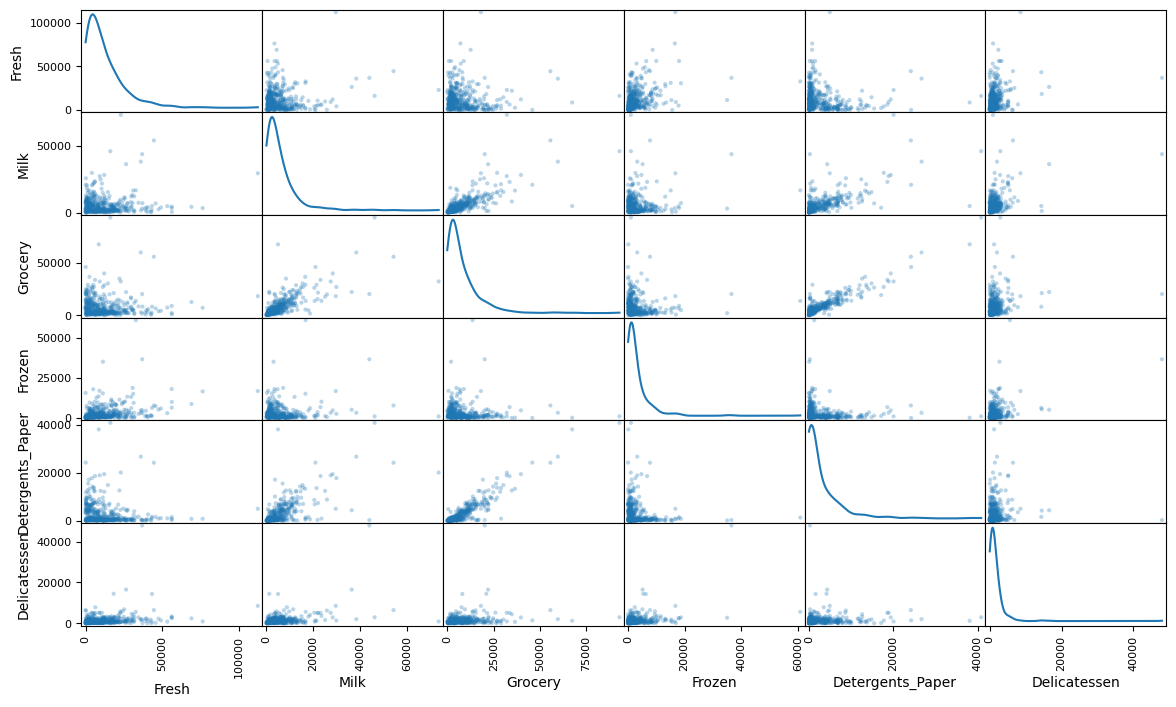

In [21]:
# Produce a scatter matrix for each pair of features in the data
pd.plotting.scatter_matrix(data, alpha = 0.3, figsize = (14,8), diagonal = 'kde')

In [17]:
data.corr()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen,Total
Fresh,1.000000,0.100510,-0.011854,0.345881,-0.101953,0.244690,0.575178
Milk,0.100510,1.000000,0.728335,0.123994,0.661816,0.406368,0.776909
Grocery,-0.011854,0.728335,1.000000,-0.040193,0.924641,0.205497,0.740680
Frozen,0.345881,0.123994,-0.040193,1.000000,-0.131525,0.390947,0.388436
Detergents_Paper,-0.101953,0.661816,0.924641,-0.131525,1.000000,0.069291,0.633882
Delicatessen,0.244690,0.406368,0.205497,0.390947,0.069291,1.000000,0.496849
Total,0.575178,0.776909,0.740680,0.388436,0.633882,0.496849,1.000000


### Question 3
* Using the scatter matrix as a reference, discuss the distribution of the dataset, specifically talk about the normality, outliers, large number of data points near 0 among others. If you need to sepearate out some of the plots individually to further accentuate your point, you may do so as well.
* Are there any pairs of features which exhibit some degree of correlation? 
* Does this confirm or deny your suspicions about the relevance of the feature you attempted to predict? 
* How is the data for those features distributed?

**Hint:** Is the data normally distributed? Where do most of the data points lie? You can use [corr()](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.corr.html) to get the feature correlations and then visualize them using a [heatmap](http://seaborn.pydata.org/generated/seaborn.heatmap.html)(the data that would be fed into the heatmap would be the correlation values, for eg: `data.corr()`) to gain further insight.

**Answer:**

* The data is not normally distributed, as we can see from the scatter matrix. There are many outliers in the data, and a large number of data points lie near 0. This indicates that there are many customers who purchase very little of the products.
* Yes, there are some features that exhibit correlation:

There is a strong positive correlation between Grocery and Detergents_Paper.
There is a moderate correlation between Milk and both Grocery and Detergents_Paper.
Other features such as Fresh, Frozen, and Delicatessen show weak or no clear correlation with the rest.
* These observations confirm the previous analysis.

Features like Grocery and Detergents_Paper are highly correlated, meaning one can be predicted from the other, so they are less unique (less important individually).
Features like Fresh and Delicatessen are not strongly correlated with other features, making them more important for identifying customer behavior.
* The correlated features (especially Grocery and Detergents_Paper) are:

Right-skewed,
Contain many small values and few large ones,
Show a clear linear relationship in the scatter plots.

This indicates that customers who spend more on grocery items also tend to spend more on detergents, which explains the strong correlation between them.

## Data Preprocessing
In this section, you will preprocess the data to create a better representation of customers by performing a scaling on the data and detecting (and optionally removing) outliers. Preprocessing data is often times a critical step in assuring that results you obtain from your analysis are significant and meaningful.

### Implementation: Feature Scaling
If data is not normally distributed, especially if the mean and median vary significantly (indicating a large skew), it is most [often appropriate](http://econbrowser.com/archives/2014/02/use-of-logarithms-in-economics) to apply a non-linear scaling — particularly for financial data. One way to achieve this scaling is by using a [Box-Cox test](http://scipy.github.io/devdocs/generated/scipy.stats.boxcox.html), which calculates the best power transformation of the data that reduces skewness. A simpler approach which can work in most cases would be applying the natural logarithm.

In the code block below, you will need to implement the following:
 - Assign a copy of the data to `log_data` after applying logarithmic scaling. Use the `np.log` function for this.
 - Assign a copy of the sample data to `log_samples` after applying logarithmic scaling. Again, use `np.log`.

In [18]:
#check data have positive values 
def check_data(data):
    """
    Check if all values in the dataset are strictly positive.
    
    """
    return (data > 0).all().all()

array([[<Axes: xlabel='Fresh', ylabel='Fresh'>,
        <Axes: xlabel='Milk', ylabel='Fresh'>,
        <Axes: xlabel='Grocery', ylabel='Fresh'>,
        <Axes: xlabel='Frozen', ylabel='Fresh'>,
        <Axes: xlabel='Detergents_Paper', ylabel='Fresh'>,
        <Axes: xlabel='Delicatessen', ylabel='Fresh'>,
        <Axes: xlabel='Total', ylabel='Fresh'>],
       [<Axes: xlabel='Fresh', ylabel='Milk'>,
        <Axes: xlabel='Milk', ylabel='Milk'>,
        <Axes: xlabel='Grocery', ylabel='Milk'>,
        <Axes: xlabel='Frozen', ylabel='Milk'>,
        <Axes: xlabel='Detergents_Paper', ylabel='Milk'>,
        <Axes: xlabel='Delicatessen', ylabel='Milk'>,
        <Axes: xlabel='Total', ylabel='Milk'>],
       [<Axes: xlabel='Fresh', ylabel='Grocery'>,
        <Axes: xlabel='Milk', ylabel='Grocery'>,
        <Axes: xlabel='Grocery', ylabel='Grocery'>,
        <Axes: xlabel='Frozen', ylabel='Grocery'>,
        <Axes: xlabel='Detergents_Paper', ylabel='Grocery'>,
        <Axes: xlabel='Delicat

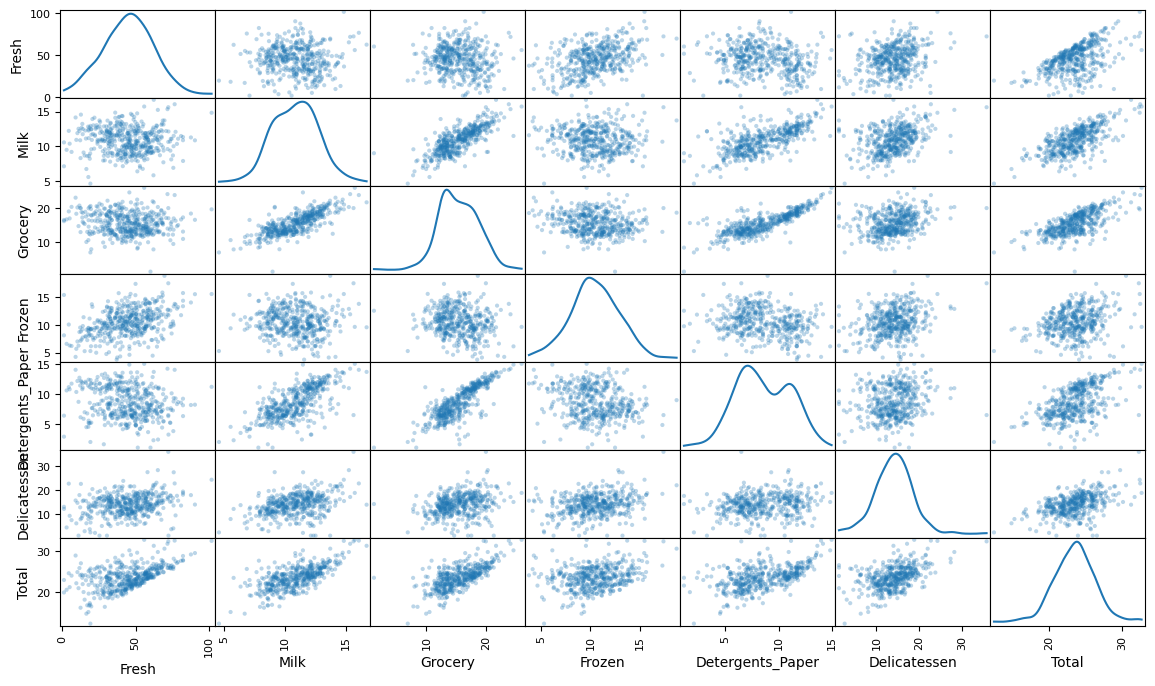

In [19]:
import numpy as np
import pandas as pd
from scipy import stats


# Copy data
boxcox_data = pd.DataFrame()
boxcox_samples = pd.DataFrame()

lambdas = {}

# Apply Box-Cox to each feature separately
if check_data(data) :
  for column in data.columns:
        transformed, lam = stats.boxcox(data[column])
        boxcox_data[column] = transformed
        lambdas[column] = lam

# Apply Box-Cox to samples
if check_data(samples) :
  for column in samples.columns:
        transformed, lam = stats.boxcox(samples[column])
        boxcox_samples[column] = transformed
        lambdas[column] = lam

pd.plotting.scatter_matrix(boxcox_data, alpha = 0.3, figsize = (14,8), diagonal = 'kde')

array([[<Axes: xlabel='Fresh', ylabel='Fresh'>,
        <Axes: xlabel='Milk', ylabel='Fresh'>,
        <Axes: xlabel='Grocery', ylabel='Fresh'>,
        <Axes: xlabel='Frozen', ylabel='Fresh'>,
        <Axes: xlabel='Detergents_Paper', ylabel='Fresh'>,
        <Axes: xlabel='Delicatessen', ylabel='Fresh'>,
        <Axes: xlabel='Total', ylabel='Fresh'>],
       [<Axes: xlabel='Fresh', ylabel='Milk'>,
        <Axes: xlabel='Milk', ylabel='Milk'>,
        <Axes: xlabel='Grocery', ylabel='Milk'>,
        <Axes: xlabel='Frozen', ylabel='Milk'>,
        <Axes: xlabel='Detergents_Paper', ylabel='Milk'>,
        <Axes: xlabel='Delicatessen', ylabel='Milk'>,
        <Axes: xlabel='Total', ylabel='Milk'>],
       [<Axes: xlabel='Fresh', ylabel='Grocery'>,
        <Axes: xlabel='Milk', ylabel='Grocery'>,
        <Axes: xlabel='Grocery', ylabel='Grocery'>,
        <Axes: xlabel='Frozen', ylabel='Grocery'>,
        <Axes: xlabel='Detergents_Paper', ylabel='Grocery'>,
        <Axes: xlabel='Delicat

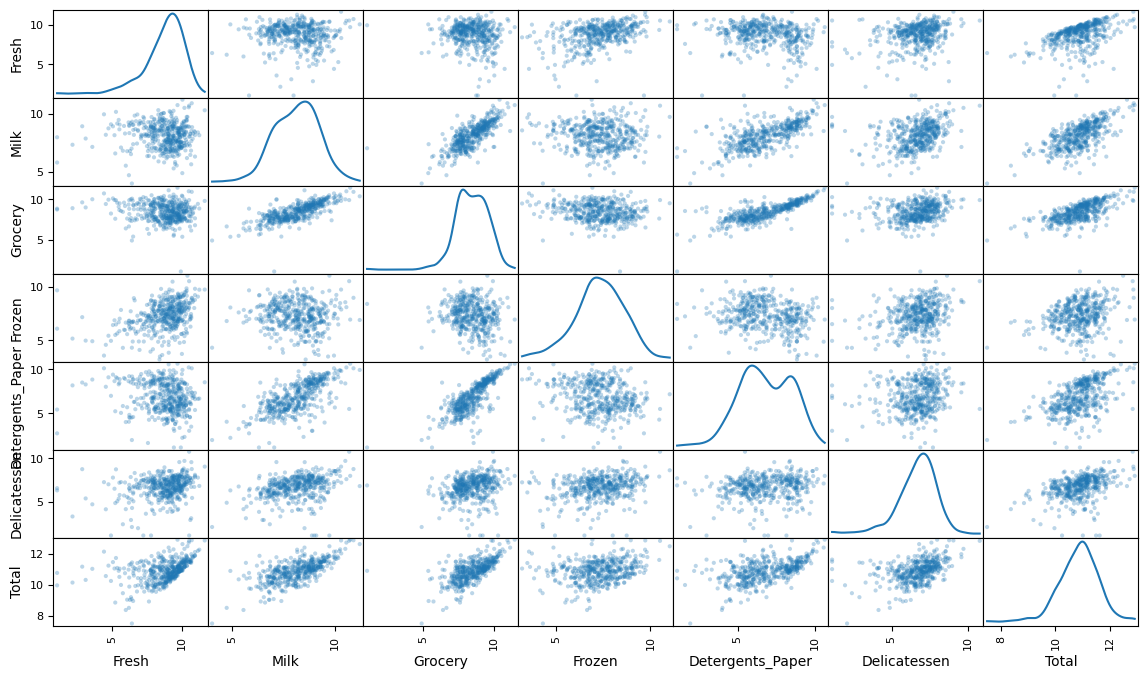

In [20]:
# TODO: Scale the data using the natural logarithm
log_data = np.log(data)

# TODO: Scale the sample data using the natural logarithm
log_samples = np.log(samples)

# Produce a scatter matrix for each pair of newly-transformed features
pd.plotting.scatter_matrix(log_data, alpha = 0.3, figsize = (14,8), diagonal = 'kde')

In [21]:
print(log_data.corr())
print("################################################################################################")
print(boxcox_data.corr())


                     Fresh      Milk   Grocery    Frozen  Detergents_Paper  \
Fresh             1.000000 -0.019834 -0.132713  0.383996         -0.155871   
Milk             -0.019834  1.000000  0.758851 -0.055316          0.677942   
Grocery          -0.132713  0.758851  1.000000 -0.164524          0.796398   
Frozen            0.383996 -0.055316 -0.164524  1.000000         -0.211576   
Detergents_Paper -0.155871  0.677942  0.796398 -0.211576          1.000000   
Delicatessen      0.255186  0.337833  0.235728  0.254718          0.166735   
Total             0.428823  0.668944  0.646225  0.267252          0.519976   

                  Delicatessen     Total  
Fresh                 0.255186  0.428823  
Milk                  0.337833  0.668944  
Grocery               0.235728  0.646225  
Frozen                0.254718  0.267252  
Detergents_Paper      0.166735  0.519976  
Delicatessen          1.000000  0.428273  
Total                 0.428273  1.000000  
###############################

## Which transformation is better (Log vs Box-Cox)?

Based on the correlation matrices of both the Log-transformed data and the Box-Cox-transformed data, Box-Cox appears to perform slightly better overall.

In the Box-Cox transformed data, the relationships between key features such as Milk, Grocery, and Detergents_Paper become slightly stronger and more stable compared to the Log transformation. For example, the correlation between Grocery and Detergents_Paper increases from approximately 0.796 (Log) to 0.818 (Box-Cox), indicating a clearer linear relationship after transformation.

This suggests that Box-Cox is more effective at normalizing the data distribution and reducing skewness, as it adapts the transformation individually for each feature using an optimal parameter (λ), rather than applying a fixed transformation like the logarithm.

Therefore, although both methods improve the data distribution, Box-Cox is generally the better choice in this case because it provides a more optimized and flexible transformation, resulting in clearer and stronger feature relationships.

### Observation
After applying a natural logarithm scaling to the data, the distribution of each feature should appear much more normal. For any pairs of features you may have identified earlier as being correlated, observe here whether that correlation is still present (and whether it is now stronger or weaker than before).

Run the code below to see how the sample data has changed after having the natural logarithm applied to it.

In [ ]:
# Display the log-transformed sample data
display(log_samples)

# Display the box-cox-transformed sample data
display(boxcox_samples)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,6.432940,4.007333,4.919981,4.317488,1.945910,2.079442
1,9.948365,7.557995,7.360740,7.580700,5.442418,6.867974
2,9.687630,10.740670,11.437986,6.933423,10.617099,7.987524


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,73.102930,4.167962,3.945918,13.720440,1.847440,2.766340
1,589.917945,8.142962,5.325693,69.437138,4.717516,19.311018
2,505.791171,11.947455,7.033163,50.950452,8.086695,27.212604


## Answer (Observation after Box-Cox Transformation)

After applying the Box-Cox transformation, the values of all features have been significantly rescaled and compressed compared to the original dataset. Large values are reduced more strongly, resulting in a more balanced representation of customer spending across all product categories.

The distribution of each feature becomes more normalized, as extreme differences between low and high spenders are reduced. This helps in making the data less skewed and more suitable for statistical analysis and machine learning models.

For the selected sample customers, the transformed values still preserve the relative differences between them. For example, Sample 0 remains a low-spending customer across all categories, while Samples 1 and 2 still represent higher-spending customers with distinct purchasing patterns. However, the gap between features is now less extreme, making comparisons more meaningful.

Overall, the Box-Cox transformation improves the structure of the data by reducing skewness and stabilizing variance while preserving the underlying relationships between features.

### Implementation: Outlier Detection
Detecting outliers in the data is extremely important in the data preprocessing step of any analysis. The presence of outliers can often skew results which take into consideration these data points. There are many "rules of thumb" for what constitutes an outlier in a dataset. Here, we will use [Tukey's Method for identfying outliers](http://datapigtechnologies.com/blog/index.php/highlighting-outliers-in-your-data-with-the-tukey-method/): An *outlier step* is calculated as 1.5 times the interquartile range (IQR). A data point with a feature that is beyond an outlier step outside of the IQR for that feature is considered abnormal.

In the code block below, you will need to implement the following:
 - Assign the value of the 25th percentile for the given feature to `Q1`. Use `np.percentile` for this.
 - Assign the value of the 75th percentile for the given feature to `Q3`. Again, use `np.percentile`.
 - Assign the calculation of an outlier step for the given feature to `step`.
 - Optionally remove data points from the dataset by adding indices to the `outliers` list.

**NOTE:** If you choose to remove any outliers, ensure that the sample data does not contain any of these points!  
Once you have performed this implementation, the dataset will be stored in the variable `good_data`.

Data points considered outliers for the feature 'Fresh':


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen,Total
181,101.573168,14.821916,19.601094,15.508049,11.172697,24.271948,32.341543


Data points considered outliers for the feature 'Milk':


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen,Total
86,62.288622,16.688055,21.679027,9.536028,13.638423,13.972231,31.165401
154,19.248393,4.596233,6.853242,5.270266,2.066981,2.552898,12.527513


Data points considered outliers for the feature 'Grocery':


...

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen,Total


Data points considered outliers for the feature 'Delicatessen':


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen,Total
23,65.063140,15.236171,20.288093,12.837630,10.951341,28.228417,29.679130
71,58.051674,9.159633,20.125298,12.927219,10.886939,27.391987,27.194772
87,75.837775,11.489218,16.917972,13.277139,9.312650,27.339710,28.080082
109,25.412566,13.704849,21.294649,8.838333,8.332239,1.222366,25.952965
128,11.185312,12.509060,14.645550,6.237032,8.696657,1.222366,21.013972
142,72.282923,12.121061,16.970633,11.699032,3.289073,1.222366,26.521351
154,19.248393,4.596233,6.853242,5.270266,2.066981,2.552898,12.527513
183,72.168679,15.617996,19.974334,17.437504,6.510175,35.778586,32.219935
184,15.333830,8.646688,15.253509,5.250524,6.983535,3.041318,18.265297
187,30.495868,12.325238,17.528036,13.262186,10.575590,1.222366,23.940571


Data points considered outliers for the feature 'Total':


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen,Total
47,76.480989,16.052046,23.823778,13.739586,13.982068,22.737981,32.409425
61,71.615840,15.341485,24.108394,11.869443,14.167679,17.158616,31.650420
85,55.798208,15.720154,25.969333,9.607978,14.972315,18.835822,32.596723
86,62.288622,16.688055,21.679027,9.536028,13.638423,13.972231,31.165401
97,16.525533,6.702971,9.943061,9.090332,4.520166,6.315679,14.909085
98,17.872539,5.548677,10.504699,9.355470,4.566683,8.068398,15.309960
131,29.039541,7.956381,8.496047,7.681565,4.854388,10.424631,16.547255
154,19.248393,4.596233,6.853242,5.270266,2.066981,2.552898,12.527513
181,101.573168,14.821916,19.601094,15.508049,11.172697,24.271948,32.341543
183,72.168679,15.617996,19.974334,17.437504,6.510175,35.778586,32.219935


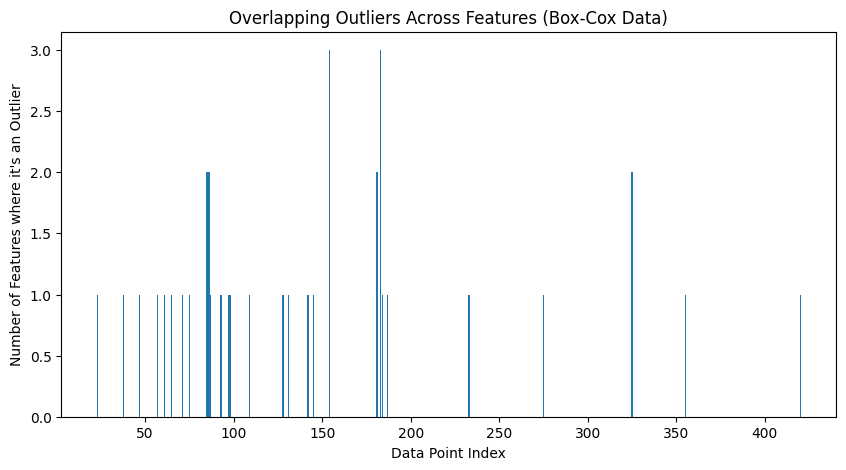

In [25]:
import matplotlib.pyplot as plt
from collections import Counter

# Collect all outlier indices across features
all_outliers = []

# For each feature find the data points with extreme high or low values
for feature in boxcox_data.columns:
    
    # TODO: Calculate Q1 (25th percentile of the data) for the given feature
    Q1 = np.percentile(boxcox_data[feature], 25)

    # TODO: Calculate Q3 (75th percentile of the data) for the given feature
    Q3 = np.percentile(boxcox_data[feature], 75)

    # TODO: Use the interquartile range to calculate an outlier step (1.5 times the interquartile range)
    step = 1.5 * (Q3 - Q1)
    
    # Get outlier indices for this feature
    feature_outliers = boxcox_data[
        ~((boxcox_data[feature] >= Q1 - step) & (boxcox_data[feature] <= Q3 + step))]
    
    # Display the outliers
    print("Data points considered outliers for the feature '{}':".format(feature))
    display(feature_outliers)
    all_outliers.extend(feature_outliers.index)

# Count how many times each index appears as an outlier
outlier_counts = Counter(all_outliers)

# Prepare data for plotting
indices = list(outlier_counts.keys())
counts = list(outlier_counts.values())

# Plot
plt.figure(figsize=(10,5))
plt.bar(indices, counts)
plt.xlabel("Data Point Index")
plt.ylabel("Number of Features where it's an Outlier")
plt.title("Overlapping Outliers Across Features (Box-Cox Data)")
plt.show()

In [26]:
outliers = [i for i, c in outlier_counts.items() if c >= 2]
print("Final outliers to remove:", outliers)

# Remove the outliers, if any were specified
good_data = boxcox_data.drop(boxcox_data.index[outliers]).reset_index(drop = True)

Final outliers to remove: [181, 86, 154, 85, 183, 325]


### Question 4
* Are there any data points considered outliers for more than one feature based on the definition above? 
* Should these data points be removed from the dataset? 
* If any data points were added to the `outliers` list to be removed, explain why.

** Hint: ** If you have datapoints that are outliers in multiple categories think about why that may be and if they warrant removal. Also note how k-means is affected by outliers and whether or not this plays a factor in your analysis of whether or not to remove them.

**Answer:**

* Yes, there are several data points that are considered outliers in more than one feature. After applying Tukey’s method across all features, we identified a set of data points that repeatedly appear as outliers in multiple product categories. The final outliers selected for removal are: [181, 86, 154, 85, 183, 325].

* These data points represent customers with highly unusual and extreme purchasing patterns compared to the rest of the dataset. Their repeated occurrence as outliers across multiple features indicates that they are not typical observations and may distort the overall data structure.

* Since K-means clustering relies on distance calculations, it is highly sensitive to extreme values. These outliers can significantly influence cluster centroids, leading to misleading or less representative clusters. Therefore, removing them helps improve the stability and quality of the clustering results.

* However, it is also important to consider that such extreme values may represent very large or highly specialized wholesale customers rather than errors. Despite this, in this analysis we chose to remove only the data points that were consistently identified as outliers across multiple features, as they are more likely to negatively impact the clustering process.

Overall, removing these outliers helps reduce noise in the dataset while preserving meaningful customer variation for further analysis.

## Feature Transformation
In this section you will use principal component analysis (PCA) to draw conclusions about the underlying structure of the wholesale customer data. Since using PCA on a dataset calculates the dimensions which best maximize variance, we will find which compound combinations of features best describe customers.

### Implementation: PCA

Now that the data has been scaled to a more normal distribution and has had any necessary outliers removed, we can now apply PCA to the `good_data` to discover which dimensions about the data best maximize the variance of features involved. In addition to finding these dimensions, PCA will also report the *explained variance ratio* of each dimension — how much variance within the data is explained by that dimension alone. Note that a component (dimension) from PCA can be considered a new "feature" of the space, however it is a composition of the original features present in the data.

In the code block below, you will need to implement the following:
 - Import `sklearn.decomposition.PCA` and assign the results of fitting PCA in six dimensions with `good_data` to `pca`.
 - Apply a PCA transformation of `log_samples` using `pca.transform`, and assign the results to `pca_samples`.

In [ ]:
print("good_data columns:", good_data.columns)
print("samples columns:", boxcox_samples.columns)
# droping 'Total' column from good_data to implement pca
good_data=good_data.drop('Total',axis=1)
print("good_data columns:", good_data.columns)

good_data columns: Index(['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper',
       'Delicatessen', 'Total'],
      dtype='object')
samples columns: Index(['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper',
       'Delicatessen'],
      dtype='object')
good_data columns: Index(['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper',
       'Delicatessen'],
      dtype='object')


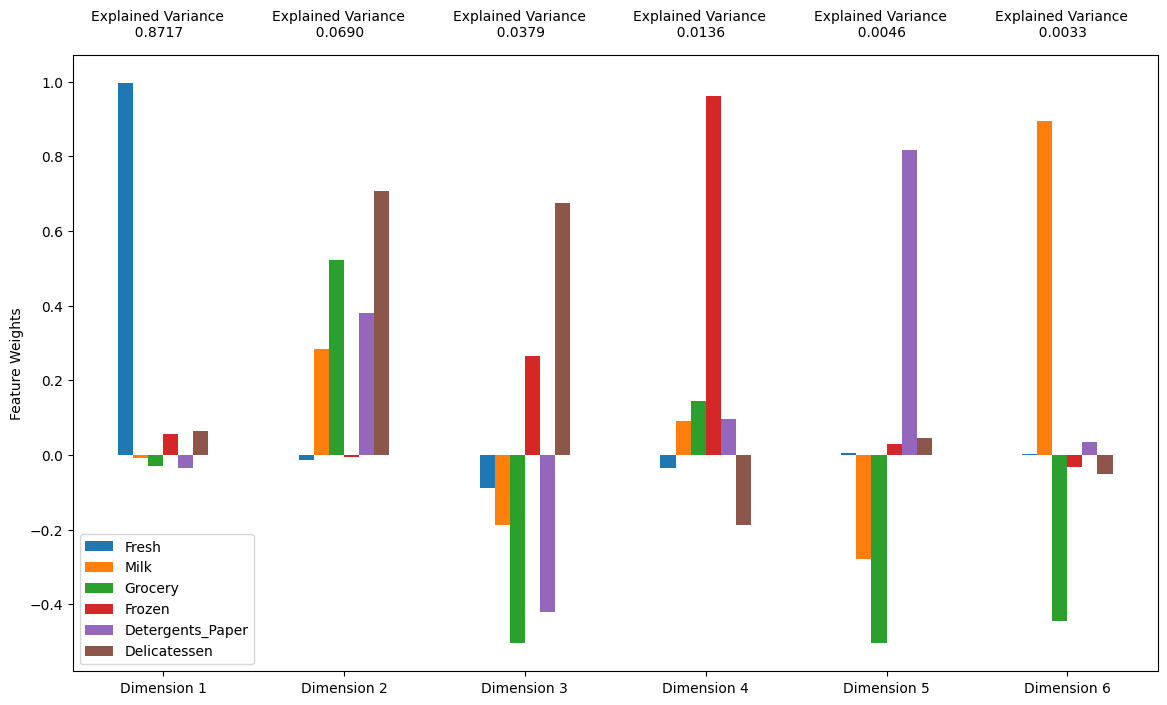

In [ ]:
from sklearn.decomposition import PCA
# TODO: Apply PCA by fitting the good data with the same number of dimensions as features
pca = PCA(n_components=6)
pca.fit(good_data)
# TODO: Transform log_samples using the PCA fit above
pca_samples = pca.transform(boxcox_samples)

# Generate PCA results plot
pca_results = vs.pca_results(good_data, pca)

### Question 5

* How much variance in the data is explained* **in total** *by the first and second principal component? 
* How much variance in the data is explained by the first four principal components? 
* Using the visualization provided above, talk about each dimension and the cumulative variance explained by each, stressing upon which features are well represented by each dimension(both in terms of positive and negative variance explained). Discuss what the first four dimensions best represent in terms of customer spending.

**Hint:** A positive increase in a specific dimension corresponds with an *increase* of the *positive-weighted* features and a *decrease* of the *negative-weighted* features. The rate of increase or decrease is based on the individual feature weights.

**Answer:**
* The total variance explained by the first and second principal components = 0.8717 + 0.0690 = 0.9407 ==> 94.07%

* The total variance explained by the first four principal components = 0.8717 + 0.0690 + 0.0379 + 00136 = 0.9922 ==> 99.22%

* Interpretation of each dimesion :

 Dimension 1 (87.17%): 

 strong positive weight(fresh), very small contribution form others 

 This represents customer who spend too much on Fresh products 

 It separates customers mainly based on Fresh spending


 Dimnsion 2 (6.9%):

 Positive: grocery - milk - delicatessen - detergents_Paper

 Customers focused on grocery-style purchasing

 Captures supermarket-like buying patterns


 Dimension 3 (3.79%):

 Negative: grocery - detergents_Paper

 Positive: delicatessen

 Separates customers who prefer: household goods (Grocery, Detergents) vs Specialty foods (Delicatessen) 


 Dimension 4 (1.36%): 

 Strong positive: frozen

 Highlights customers spending more on Frozen products
 

 Dimension 5 (0.46%): 

 Positive: detergents_Paper

 Negative: grocery

 Differentiates cleaning supplies vs food purchases


 Dimension 6 (0.33%):

 Positive: milk

 Negative: grocery

 Minor variation between dairy-focused and grocery-focused spending


### Observation
Run the code below to see how the log-transformed sample data has changed after having a PCA transformation applied to it in six dimensions. Observe the numerical value for the first four dimensions of the sample points. Consider if this is consistent with your initial interpretation of the sample points.

In [39]:
# Display sample log-data after having a PCA transformation applied
display(pd.DataFrame(np.round(pca_samples, 4), columns = pca_results.index.values))

,Dimension 1,Dimension 2,Dimension 3,Dimension 4,Dimension 5,Dimension 6
0,28.4980,-18.7147,0.6107,1.3814,1.8925,-0.6065
1,546.9254,-11.1469,-22.4558,34.7223,7.6259,0.4268
2,462.4373,-1.0898,-17.4562,19.3043,7.8201,3.2765


### Implementation: Dimensionality Reduction
When using principal component analysis, one of the main goals is to reduce the dimensionality of the data — in effect, reducing the complexity of the problem. Dimensionality reduction comes at a cost: Fewer dimensions used implies less of the total variance in the data is being explained. Because of this, the *cumulative explained variance ratio* is extremely important for knowing how many dimensions are necessary for the problem. Additionally, if a signifiant amount of variance is explained by only two or three dimensions, the reduced data can be visualized afterwards.

In the code block below, you will need to implement the following:
 - Assign the results of fitting PCA in two dimensions with `good_data` to `pca`.
 - Apply a PCA transformation of `good_data` using `pca.transform`, and assign the results to `reduced_data`.
 - Apply a PCA transformation of `log_samples` using `pca.transform`, and assign the results to `pca_samples`.

In [40]:
# TODO: Apply PCA by fitting the good data with only two dimensions
pca = PCA(n_components=2)
pca.fit(good_data)
# TODO: Transform the good data using the PCA fit above
reduced_data = pca.transform(good_data)

# TODO: Transform log_samples using the PCA fit above
pca_samples = pca.transform(boxcox_samples)

# Create a DataFrame for the reduced data
reduced_data = pd.DataFrame(reduced_data, columns = ['Dimension 1', 'Dimension 2'])

### Observation
Run the code below to see how the log-transformed sample data has changed after having a PCA transformation applied to it using only two dimensions. Observe how the values for the first two dimensions remains unchanged when compared to a PCA transformation in six dimensions.

In [41]:
# Display sample log-data after applying PCA transformation in two dimensions
display(pd.DataFrame(np.round(pca_samples, 4), columns = ['Dimension 1', 'Dimension 2']))

,Dimension 1,Dimension 2
0,28.4980,-18.7147
1,546.9254,-11.1469
2,462.4373,-1.0898


## Visualizing a Biplot
A biplot is a scatterplot where each data point is represented by its scores along the principal components. The axes are the principal components (in this case `Dimension 1` and `Dimension 2`). In addition, the biplot shows the projection of the original features along the components. A biplot can help us interpret the reduced dimensions of the data, and discover relationships between the principal components and original features.

Run the code cell below to produce a biplot of the reduced-dimension data.

<Axes: title={'center': 'PC plane with original feature projections.'}, xlabel='Dimension 1', ylabel='Dimension 2'>

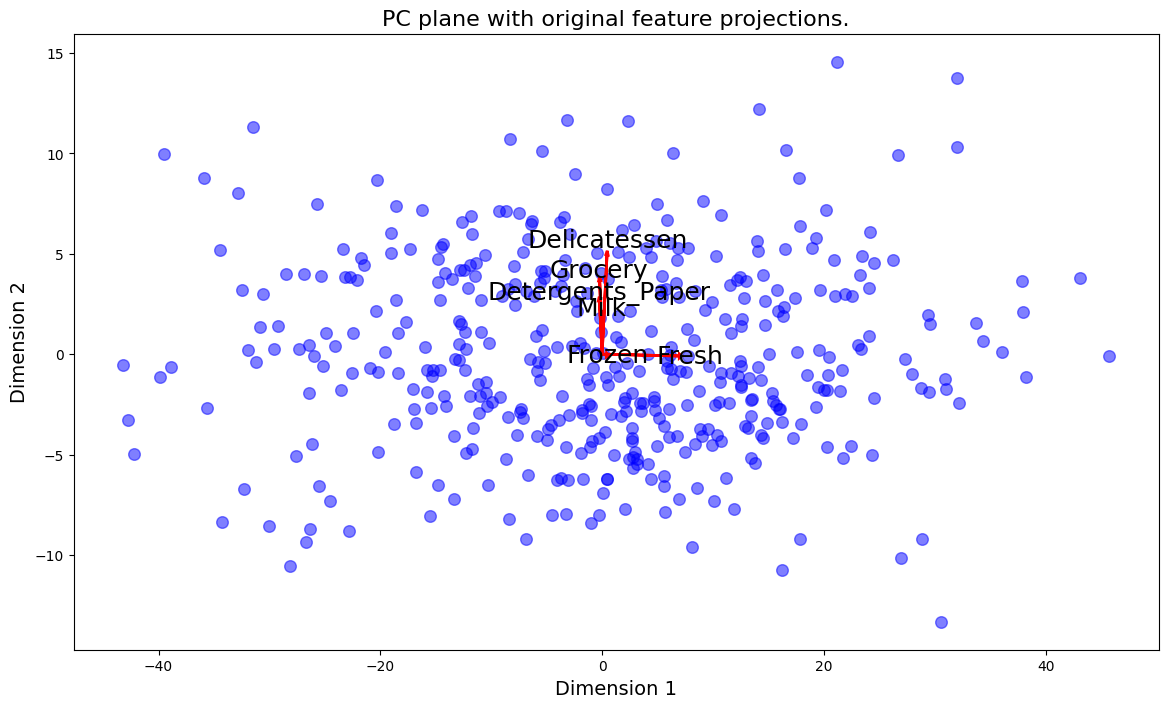

In [42]:
# Create a biplot
vs.biplot(good_data, reduced_data, pca)

### Observation

Once we have the original feature projections (in red), it is easier to interpret the relative position of each data point in the scatterplot. For instance, a point the lower right corner of the figure will likely correspond to a customer that spends a lot on `'Milk'`, `'Grocery'` and `'Detergents_Paper'`, but not so much on the other product categories. 

From the biplot, which of the original features are most strongly correlated with the first component? What about those that are associated with the second component? Do these observations agree with the pca_results plot you obtained earlier?

## Clustering

In this section, you will choose to use either a K-Means clustering algorithm or a Gaussian Mixture Model clustering algorithm to identify the various customer segments hidden in the data. You will then recover specific data points from the clusters to understand their significance by transforming them back into their original dimension and scale. 

### Question 6

* What are the advantages to using a K-Means clustering algorithm? 
* What are the advantages to using a Gaussian Mixture Model clustering algorithm? 
* Given your observations about the wholesale customer data so far, which of the two algorithms will you use and why?

** Hint: ** Think about the differences between hard clustering and soft clustering and which would be appropriate for our dataset.

**Answer:**

### Implementation: Creating Clusters
Depending on the problem, the number of clusters that you expect to be in the data may already be known. When the number of clusters is not known *a priori*, there is no guarantee that a given number of clusters best segments the data, since it is unclear what structure exists in the data — if any. However, we can quantify the "goodness" of a clustering by calculating each data point's *silhouette coefficient*. The [silhouette coefficient](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html) for a data point measures how similar it is to its assigned cluster from -1 (dissimilar) to 1 (similar). Calculating the *mean* silhouette coefficient provides for a simple scoring method of a given clustering.

In the code block below, you will need to implement the following:
 - Fit a clustering algorithm to the `reduced_data` and assign it to `clusterer`.
 - Predict the cluster for each data point in `reduced_data` using `clusterer.predict` and assign them to `preds`.
 - Find the cluster centers using the algorithm's respective attribute and assign them to `centers`.
 - Predict the cluster for each sample data point in `pca_samples` and assign them `sample_preds`.
 - Import `sklearn.metrics.silhouette_score` and calculate the silhouette score of `reduced_data` against `preds`.
   - Assign the silhouette score to `score` and print the result.

In [ ]:
# TODO: Apply your clustering algorithm of choice to the reduced data 
clusterer = None

# TODO: Predict the cluster for each data point
preds = None

# TODO: Find the cluster centers
centers = None

# TODO: Predict the cluster for each transformed sample data point
sample_preds = None

# TODO: Calculate the mean silhouette coefficient for the number of clusters chosen
score = None

### Question 7

* Report the silhouette score for several cluster numbers you tried. 
* Of these, which number of clusters has the best silhouette score?

**Answer:**

### Cluster Visualization
Once you've chosen the optimal number of clusters for your clustering algorithm using the scoring metric above, you can now visualize the results by executing the code block below. Note that, for experimentation purposes, you are welcome to adjust the number of clusters for your clustering algorithm to see various visualizations. The final visualization provided should, however, correspond with the optimal number of clusters. 

In [ ]:
# Display the results of the clustering from implementation
vs.cluster_results(reduced_data, preds, centers, pca_samples)

### Implementation: Data Recovery
Each cluster present in the visualization above has a central point. These centers (or means) are not specifically data points from the data, but rather the *averages* of all the data points predicted in the respective clusters. For the problem of creating customer segments, a cluster's center point corresponds to *the average customer of that segment*. Since the data is currently reduced in dimension and scaled by a logarithm, we can recover the representative customer spending from these data points by applying the inverse transformations.

In the code block below, you will need to implement the following:
 - Apply the inverse transform to `centers` using `pca.inverse_transform` and assign the new centers to `log_centers`.
 - Apply the inverse function of `np.log` to `log_centers` using `np.exp` and assign the true centers to `true_centers`.


In [ ]:
# TODO: Inverse transform the centers
log_centers = None

# TODO: Exponentiate the centers
true_centers = None

# Display the true centers
segments = ['Segment {}'.format(i) for i in range(0,len(centers))]
true_centers = pd.DataFrame(np.round(true_centers), columns = data.keys())
true_centers.index = segments
display(true_centers)

### Question 8

* Consider the total purchase cost of each product category for the representative data points above, and reference the statistical description of the dataset at the beginning of this project(specifically looking at the mean values for the various feature points). What set of establishments could each of the customer segments represent?

**Hint:** A customer who is assigned to `'Cluster X'` should best identify with the establishments represented by the feature set of `'Segment X'`. Think about what each segment represents in terms their values for the feature points chosen. Reference these values with the mean values to get some perspective into what kind of establishment they represent.

**Answer:**

### Question 9

* For each sample point, which customer segment from* **Question 8** *best represents it? 
* Are the predictions for each sample point consistent with this?*

Run the code block below to find which cluster each sample point is predicted to be.

In [ ]:
# Display the predictions
for i, pred in enumerate(sample_preds):
    print("Sample point", i, "predicted to be in Cluster", pred)

**Answer:**

## Conclusion

In this final section, you will investigate ways that you can make use of the clustered data. First, you will consider how the different groups of customers, the ***customer segments***, may be affected differently by a specific delivery scheme. Next, you will consider how giving a label to each customer (which *segment* that customer belongs to) can provide for additional features about the customer data. Finally, you will compare the ***customer segments*** to a hidden variable present in the data, to see whether the clustering identified certain relationships.

### Question 10
Companies will often run [A/B tests](https://en.wikipedia.org/wiki/A/B_testing) when making small changes to their products or services to determine whether making that change will affect its customers positively or negatively. The wholesale distributor is considering changing its delivery service from currently 5 days a week to 3 days a week. However, the distributor will only make this change in delivery service for customers that react positively. 

* How can the wholesale distributor use the customer segments to determine which customers, if any, would react positively to the change in delivery service?*

**Hint:** Can we assume the change affects all customers equally? How can we determine which group of customers it affects the most?

**Answer:**

### Question 11
Additional structure is derived from originally unlabeled data when using clustering techniques. Since each customer has a ***customer segment*** it best identifies with (depending on the clustering algorithm applied), we can consider *'customer segment'* as an **engineered feature** for the data. Assume the wholesale distributor recently acquired ten new customers and each provided estimates for anticipated annual spending of each product category. Knowing these estimates, the wholesale distributor wants to classify each new customer to a ***customer segment*** to determine the most appropriate delivery service.  
* How can the wholesale distributor label the new customers using only their estimated product spending and the **customer segment** data?

**Hint:** A supervised learner could be used to train on the original customers. What would be the target variable?

**Answer:**

### Visualizing Underlying Distributions

At the beginning of this project, it was discussed that the `'Channel'` and `'Region'` features would be excluded from the dataset so that the customer product categories were emphasized in the analysis. By reintroducing the `'Channel'` feature to the dataset, an interesting structure emerges when considering the same PCA dimensionality reduction applied earlier to the original dataset.

Run the code block below to see how each data point is labeled either `'HoReCa'` (Hotel/Restaurant/Cafe) or `'Retail'` the reduced space. In addition, you will find the sample points are circled in the plot, which will identify their labeling.

In [ ]:
# Display the clustering results based on 'Channel' data
vs.channel_results(reduced_data, outliers, pca_samples)

### Question 12

* How well does the clustering algorithm and number of clusters you've chosen compare to this underlying distribution of Hotel/Restaurant/Cafe customers to Retailer customers? 
* Are there customer segments that would be classified as purely 'Retailers' or 'Hotels/Restaurants/Cafes' by this distribution? 
* Would you consider these classifications as consistent with your previous definition of the customer segments?

**Answer:**

> **Note**: Once you have completed all of the code implementations and successfully answered each question above, you may finalize your work by exporting the iPython Notebook as an HTML document. You can do this by using the menu above and navigating to  
**File -> Download as -> HTML (.html)**. Include the finished document along with this notebook as your submission.